In [ ]:
# This python notebook is for a hands-on tutorial on the conception of pulsar search, the material is developed by Prof. Jason Hessels of U. Amsterdam and McGill
# I also modified a solution provided by Dr. Ziggy Pleunis (UvA/ASTRON) 

#The input file is a dedispersed timeseries from LOFAR of the original pulsar PSR B1919+21


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage

#Read file to get the time series (ts)
ts = np.fromfile("L197621_SAP0_BEAM1_DM12.44_Mask.dat", dtype=np.float32)

#Check the length of the time series to find out the total number of samples. 
nsamp = 

#The sampling rate of this observation
tsamp = 0.00262143998406827

#The integration time (t)
t = np.arange(nsamp) * tsamp

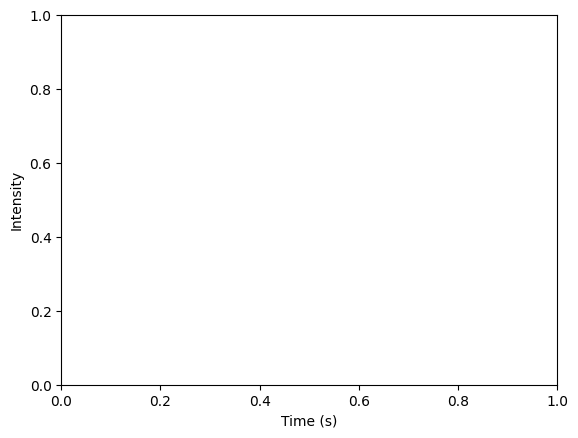

In [8]:
# check data
plt.plot(t, ts)
plt.ylabel("Intensity")
plt.xlabel("Time (s)")
plt.show()


Text(0.5, 0, 'Time (s)')

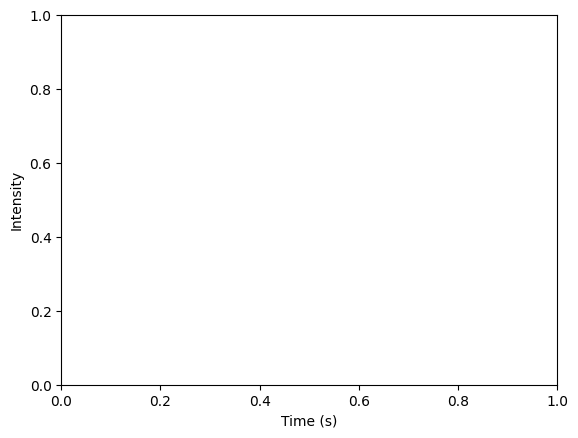

In [10]:
# The baseline of this time series is not flat, we will need to filter out this red noise
# Hint: use scipy.ndimage.uniform_filter1d to calculate a running mean in order to normalize the data
# Hint: need to play with window size when data and/or tsamp changes

running_mean = 
normalized = 
plt.plot(t, normalized)
plt.ylabel("Intensity")
plt.xlabel("Time (s)")

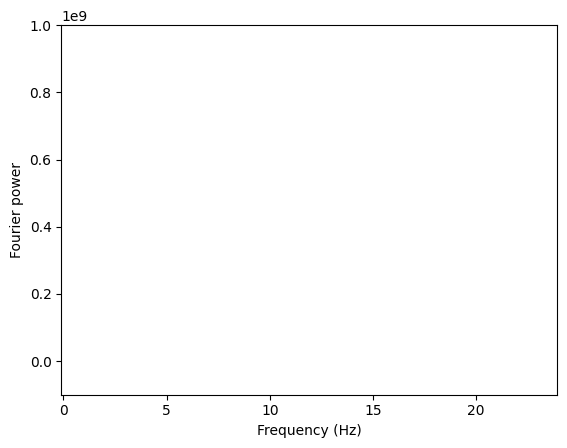

In [13]:
# Run a Fourier transform on the time series ts to find any periodicity in the data
# Hint: use np.fft.rfft and np.fft.rfftfreq
fft = 
xf = 
plt.plot(xf, fft)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Fourier power")


# Add to the plot the spin period of PSR B1919+21 to see if they match up
# Hint: get the spin period in seconds from the internet, e.g. the ATNF catalog https://www.atnf.csiro.au/research/pulsar/psrcat/
p0 = 
f0 = 

# plot harmonics
for i in range(1, 32):
    plt.axvline(i * f0, color="tab:orange", ls=":")
plt.xlim(-0.1, f0 * 32)
plt.ylim(-0.1e9, 1e9)

plt.show()

In [38]:
# The giant peak near 0 Hz is the DC component
# It is there because the total intensity in our data is always positive, 
# the baseline noise has nonzero mean, and we did not subtract the mean.
# Just ignore that for now, and print the next peak (which should also conincide with the orange lines)
# In order to get the spin frequency

Peak = 

/var/folders/g4/9xmh6cjn4zn7r24hvcfswgz1wj7pk0/T/ipykernel_61743/2484006407.py:33: RuntimeWarning: invalid value encountered in divide
  data = data_sum / data_count


Text(0.5, 0, 'Phase')

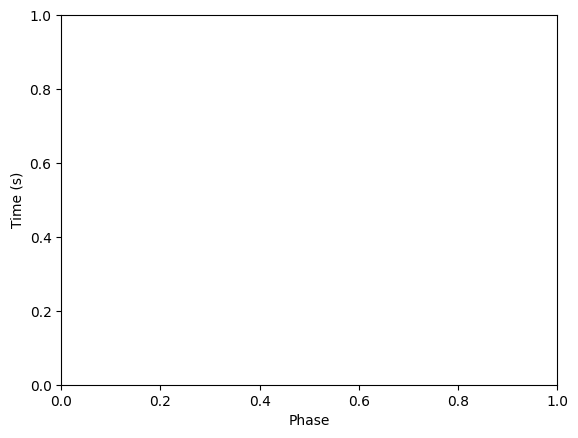

In [37]:
# create a dynamic profile of time in y and phase in x

# Try different tsub factors and see how that changes the resolution of the profile
tsub = 
# Find the number of subintegration (nsub), considering the length of the ts
nsub = 
print('nsub', nsub)

# fbin is the number of time samples per pulse period
fbin = 

# set nbin to be the nearest power of 2. This is a standard pulsar-folding trick so that the folding 
# would be most optimized if it is done using an FFT. Although not the case here, we will stick to the convention
nbin = int(2 ** np.floor(np.log2(fbin)))
print('nbin', nbin)

# sum of all samples falling in subintegration i, phase bin j
data_sum = np.zeros((nsub, nbin))

# data_count counts how many samples fell into each cell
# This is important because your sampling and folding do not guarantee exactly one sample per bin.
data_count = np.zeros((nsub, nbin))

# Compute Pulse Phase for each t
# Hint: phase should be a numpy.ndarray with the same shape as t
phase = 

# Convert Phase to Bin Index ibin
# Hint: ibin is also a numpy.ndarray again same shape
ibin = 

# Convert t to Subintegration Index
# Hint: isub is also a numpy.ndarray again same shape
isub = 

# For each sample, go to (subin, phase bin) add its intensity value
np.add.at(data_sum, (isub, ibin), ts)
# count how many samples fell into each (sub, phase) cell
np.add.at(data_count, (isub, ibin), 1.0)

# computes the average intensity per bin
data = data_sum / data_count

plt.imshow(data, origin="lower", aspect="auto", extent=[0, 1, 0, nsub * tsub])
plt.ylabel("Time (s)")
plt.xlabel("Phase")

In [14]:
# This pulsar is actually in a binary system. The orbital motion means that the observed spin period varies with time
# Try to detect this change by repeating the FFT calculation but for smaller chunk of data 
# For example, collect 10+ pairs of [time,spin_freq] and fill them into arrays mjd and frequencies

# Epoch of observation - this is the start of the file
mjd1 = 56667.642501096037449

mjd = np.array([
    
])

frequencies = np.array([
    
])

p0s = 1 / frequencies

/var/folders/g4/9xmh6cjn4zn7r24hvcfswgz1wj7pk0/T/ipykernel_61743/3232014801.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'Spin period (ms)')

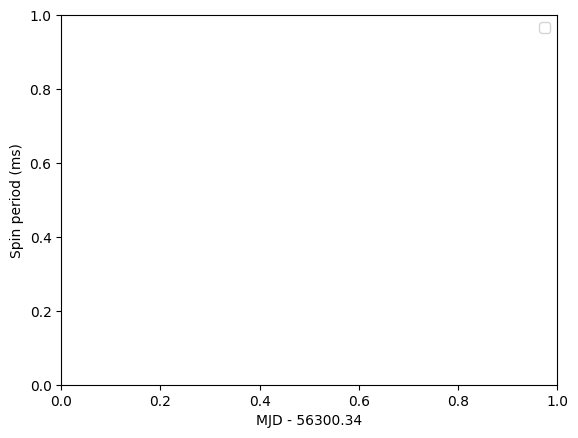

In [32]:
# fitting binary orbit

def binary_orbit(t, amp, pb, phase, offset):
    return amp * np.sin(2 * np.pi * (1 / pb) * t + phase) + offset

# This need to start at zero so we subtract np.min(mjd)
xt = np.linspace(np.min(mjd), np.max(mjd), 1000) - np.min(mjd)

# Plot the 10+ pairs of data obtained, and try to guess the binary orbit
plt.errorbar(mjd - np.min(mjd), p0s * 1000, fmt=".", color="tab:blue")
amp_guess = 
pb_guess = 
phase_guess = np.pi
offset_guess = 
#Feed these 5 input parameters to function(binary_orbit) to get a guess of the orbit
orbit_guess = 
plt.plot(xt, orbit_guess, label="guess")

# Use scipy.optimize.curve_fit to fit to the 10 pairs of data collected
import scipy.optimize
popt, pcov = 
#Feed the popt obtained to function(binary_orbit) to get a fit of the orbit
orbit_fitted = 
plt.plot(xt, orbit_fitted , label="fit")

plt.legend()
plt.xlabel("MJD - {:.2f}".format(np.min(mjd)))
plt.ylabel("Spin period (ms)")

In [ ]:
# If extra time, can try the following:

# Do zero-padding FFT. how does that change the Fourier spectrum and the determination of the spin frequencies?
# Plot intensity profiles at different frequencies, does the width of the pulse stay constant?
#